In [ ]:
# Cell 1: Upload dan ekstrak dataset
from google.colab import files
import zipfile
import os

uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
    print("Ekstrak selesai")

!ls /content/dataset

Saving dataset_kopi_224x224_q85.zip to dataset_kopi_224x224_q85 (1).zip
Ekstrak selesai
dataset_kopi_final


In [ ]:
# Cell 2: Import library
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import os

In [ ]:
# Cell 3: Setup path dataset
train_path = '/content/dataset/dataset_kopi_final/Marged/train'
val_path = '/content/dataset/dataset_kopi_final/Marged/val'

In [ ]:
# Cell 4: Data generator dengan augmentasi
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.15
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    train_path, target_size=(224,224), batch_size=32,
    class_mode='categorical', shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_path, target_size=(224,224), batch_size=32,
    class_mode='categorical', shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print("Kelas:", class_names)

Found 8000 images belonging to 4 classes.
Found 2000 images belonging to 4 classes.
Kelas: ['asalan', 'premium_grade_1', 'rusak', 'specialty_brazil']


In [ ]:
# Cell 5: Build MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Cell 6: Training Phase 1 dengan arsitektur lebih kompleks
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_dir = '/content/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-7),
    ModelCheckpoint(filepath=os.path.join(checkpoint_dir, 'model_best.h5'),
                    monitor='val_accuracy', save_best_only=True)
]

print("Phase 1: Feature Extraction")
history1 = model.fit(train_gen, validation_data=val_gen, epochs=30, callbacks=callbacks)

Phase 1: Feature Extraction
Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.5059 - loss: 1.1669

250/250 ━━━━━━━━━━━━━━━━━━━━ 130s 471ms/step - accuracy: 0.5320 - loss: 1.0041 - val_accuracy: 0.5685 - val_loss: 0.8330 - learning_rate: 0.0010
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 104s 416ms/step - accuracy: 0.5579 - loss: 0.8128 - val_accuracy: 0.5510 - val_loss: 0.7648 - learning_rate: 0.0010
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 406ms/step - accuracy: 0.5685 - loss: 0.7731 - val_accuracy: 0.5670 - val_loss: 0.7344 - learning_rate: 0.0010
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.5691 - loss: 0.7603

250/250 ━━━━━━━━━━━━━━━━━━━━ 103s 412ms/step - accuracy: 0.5692 - loss: 0.7616 - val_accuracy: 0.5755 - val_loss: 0.7442 - learning_rate: 0.0010
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 404ms/step - accuracy: 0.5810 - loss: 0.7456 - val_accuracy: 0.5720 - val_loss: 0.7278 - learning_rate: 0.0010
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 406ms/step - accuracy: 0.5842 - loss: 0.7311 - val_accuracy: 0.5620 - val_loss: 0.7506 - learning_rate: 0.0010
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.5784 - loss: 0.7406

250/250 ━━━━━━━━━━━━━━━━━━━━ 102s 406ms/step - accuracy: 0.5842 - loss: 0.7274 - val_accuracy: 0.5890 - val_loss: 0.7157 - learning_rate: 0.0010
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 99s 395ms/step - accuracy: 0.5846 - loss: 0.7438 - val_accuracy: 0.5780 - val_loss: 0.7226 - learning_rate: 0.0010
Epoch 9/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 103s 409ms/step - accuracy: 0.5860 - loss: 0.7276 - val_accuracy: 0.5710 - val_loss: 0.7321 - learning_rate: 0.0010
Epoch 10/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 142s 411ms/step - accuracy: 0.5832 - loss: 0.7209 - val_accuracy: 0.5640 - val_loss: 0.7361 - learning_rate: 0.0010
Epoch 11/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 405ms/step - accuracy: 0.5886 - loss: 0.7213 - val_accuracy: 0.5735 - val_loss: 0.7052 - learning_rate: 0.0010
Epoch 12/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 403ms/step - accuracy: 0.5851 - loss: 0.7167 - val_accuracy: 0.5735 - val_loss: 0.7038 - learning_rate: 0.0010
Epoch 13/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 406ms/step - accuracy: 0.58

In [ ]:
# Cell 7: Fine-tuning lebih agresif
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Phase 2: Fine-tuning")
history2 = model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=callbacks)

Phase 2: Fine-tuning
Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 131s 448ms/step - accuracy: 0.5800 - loss: 0.7871 - val_accuracy: 0.5750 - val_loss: 0.7195 - learning_rate: 1.0000e-05
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 105s 419ms/step - accuracy: 0.5919 - loss: 0.7485 - val_accuracy: 0.5655 - val_loss: 0.7278 - learning_rate: 1.0000e-05
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 104s 414ms/step - accuracy: 0.5959 - loss: 0.7315 - val_accuracy: 0.5710 - val_loss: 0.7187 - learning_rate: 1.0000e-05
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 103s 410ms/step - accuracy: 0.6050 - loss: 0.7157 - val_accuracy: 0.5730 - val_loss: 0.7143 - learning_rate: 1.0000e-05
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 405ms/step - accuracy: 0.5979 - loss: 0.7106 - val_accuracy: 0.5785 - val_loss: 0.7129 - learning_rate: 1.0000e-05
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 406ms/step - accuracy: 0.6119 - loss: 0.7077 - val_accuracy: 0.5760 - val_loss: 0.7086 - learning_rate: 5.0000e-06
Epoch 7/20
250/250 

In [ ]:
# Cell 8: Augmentasi lebih agresif
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    shear_range=0.2,
    fill_mode='nearest'
)

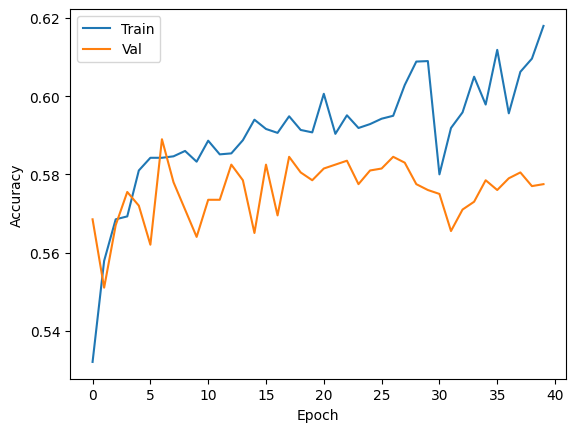

In [ ]:
# Cell 8: Plot hasil
plt.plot(history1.history['accuracy'] + history2.history['accuracy'], label='Train')
plt.plot(history1.history['val_accuracy'] + history2.history['val_accuracy'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Cell 9: Evaluasi
loss, acc = model.evaluate(val_gen)
print(f"Validation Accuracy: {acc:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5750 - loss: 0.7195
Validation Accuracy: 0.5750


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Cell 10: Classification Report
y_true = val_gen.classes
y_pred = np.argmax(model.predict(val_gen), axis=1)
print(classification_report(y_true, y_pred, target_names=class_names))

63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 120ms/step
                  precision    recall  f1-score   support

          asalan       0.50      0.32      0.39       500
 premium_grade_1       0.41      0.60      0.49       500
           rusak       1.00      0.99      0.99       500
specialty_brazil       0.42      0.39      0.41       500

        accuracy                           0.57      2000
       macro avg       0.58      0.57      0.57      2000
    weighted avg       0.58      0.57      0.57      2000



63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step


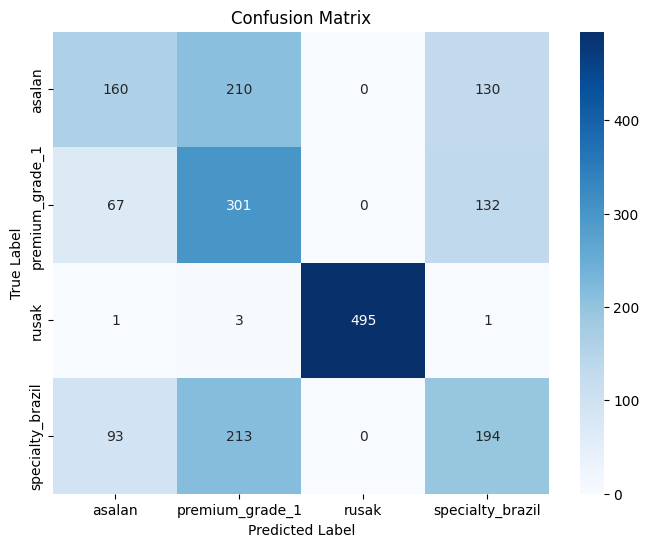

In [ ]:
# Cell 11: Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = val_gen.classes
y_pred = np.argmax(model.predict(val_gen), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

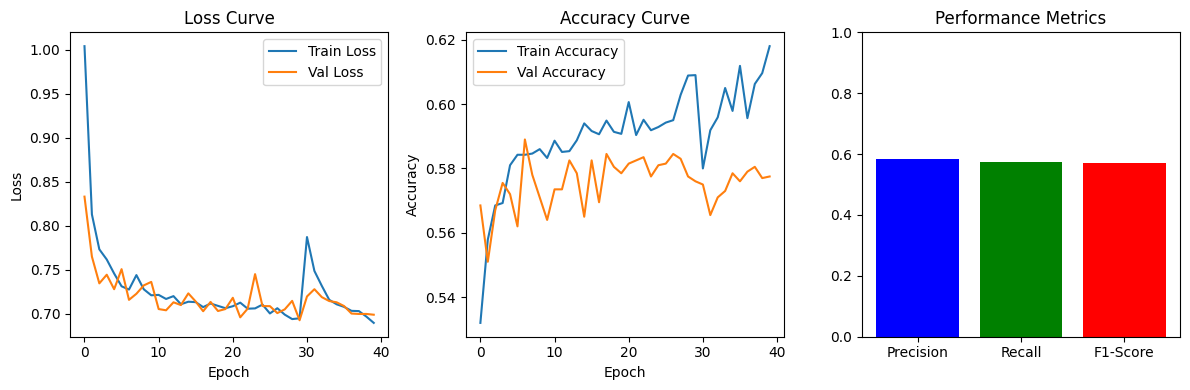

Precision: 0.5842
Recall: 0.5750
F1-Score: 0.5702


In [ ]:
# Cell 12: Grafik Loss
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(history1.history['loss'] + history2.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'] + history2.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1,3,2)
acc_all = history1.history['accuracy'] + history2.history['accuracy']
val_acc_all = history1.history['val_accuracy'] + history2.history['val_accuracy']
plt.plot(acc_all, label='Train Accuracy')
plt.plot(val_acc_all, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')

plt.subplot(1,3,3)
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
plt.bar(['Precision', 'Recall', 'F1-Score'], [precision, recall, f1], color=['blue', 'green', 'red'])
plt.ylim(0,1)
plt.title('Performance Metrics')

plt.tight_layout()
plt.show()

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

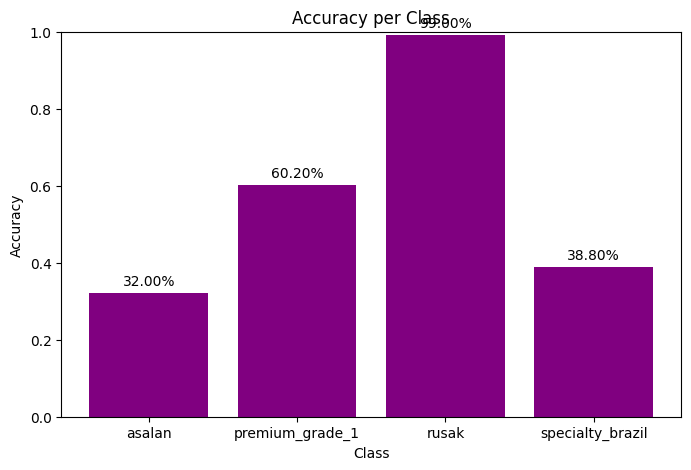

asalan: 32.00%
premium_grade_1: 60.20%
rusak: 99.00%
specialty_brazil: 38.80%


In [ ]:
# Cell 13: Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8,5))
plt.bar(class_names, per_class_acc, color='purple')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Accuracy per Class')
plt.ylim(0,1)
for i, v in enumerate(per_class_acc):
    plt.text(i, v + 0.02, f'{v:.2%}', ha='center')
plt.show()

for i, kelas in enumerate(class_names):
    print(f"{kelas}: {per_class_acc[i]:.2%}")

In [ ]:
# Cell 14: Kesimpulan Klasifikasi Mutu untuk Ekspor
print("="*60)
print("SISTEM IDENTIFIKASI MUTU BIJI KOPI UNTUK STANDARISASI EKSPOR")
print("="*60)

y_pred_classes = np.argmax(model.predict(val_gen), axis=1)
y_true_classes = val_gen.classes

hasil_identifikasi = []
for i in range(len(y_pred_classes)):
    pred_label = class_names[y_pred_classes[i]]
    true_label = class_names[y_true_classes[i]]
    if pred_label == true_label:
        status = "BENAR"
    else:
        status = "SALAH"
    hasil_identifikasi.append({
        'Asli': true_label,
        'Prediksi': pred_label,
        'Status': status
    })

print("\nREKOMENDASI KELAS UNTUK EKSPOR:")
print("-"*60)
print("1. SPECIALTY BRAZIL   : Kualitas tertinggi, layak ekspor premium")
print("2. PREMIUM GRADE 1    : Kualitas baik, layak ekspor standar")
print("3. ASALAN             : Kualitas sedang, perlu pemrosesan ulang")
print("4. RUSAK              : Tidak layak ekspor, harus disortir")

print("\nHASIL EVALUASI MODEL:")
print("-"*60)
for kelas in class_names:
    idx = class_names.index(kelas)
    akurasi_kelas = per_class_acc[idx]
    if akurasi_kelas >= 0.8:
        rekom = "LAYAK EKSPOR (Kualitas Terjamin)"
    elif akurasi_kelas >= 0.6:
        rekom = "LAYAK EKSPOR (Perlu Verifikasi Manual)"
    else:
        rekom = "TIDAK LAYAK EKSPOR (Akurasi Rendah)"

    print(f"{kelas.upper():20s} : Akurasi {akurasi_kelas:.2%} - {rekom}")

print("\nPREDIKSI PADA DATA VALIDASI (2000 sampel):")
print("-"*60)
from collections import Counter
prediksi_distribusi = Counter([hasil['Prediksi'] for hasil in hasil_identifikasi])
for kelas in class_names:
    jumlah = prediksi_distribusi.get(kelas, 0)
    print(f"{kelas.upper():20s} : {jumlah:4d} sampel teridentifikasi")

print("\nKESIMPULAN AKHIR:")
print("-"*60)
if per_class_acc[class_names.index('specialty_brazil')] >= 0.8:
    print("BIJI KOPI SPECIALTY BRAZIL teridentifikasi dengan baik")
    print("  -> LAYAK UNTUK EKSPOR KE PASAR PREMIUM")
else:
    print("BIJI KOPI SPECIALTY BRAZIL perlu peningkatan akurasi")

if per_class_acc[class_names.index('premium_grade_1')] >= 0.7:
    print("BIJI KOPI PREMIUM GRADE 1 teridentifikasi dengan baik")
    print("  -> LAYAK UNTUK EKSPOR STANDAR")
else:
    print("BIJI KOPI PREMIUM GRADE 1 perlu verifikasi manual")

if per_class_acc[class_names.index('rusak')] >= 0.9:
    print("BIJI KOPI RUSAK teridentifikasi dengan sangat baik")
    print("  -> REKOMENDASI: SORTIR SEBELUM EKSPOR")
else:
    print("Identifikasi biji rusak perlu ditingkatkan")

akurasi_total = sum(per_class_acc) / len(per_class_acc)
print(f"\nAKURASI TOTAL SISTEM: {akurasi_total:.2%}")
if akurasi_total >= 0.75:
    print("SISTEM LAYAK DIGUNAKAN UNTUK STANDARISASI EKSPOR")
elif akurasi_total >= 0.6:
    print("SISTEM PERLU PERBAIKAN SEBELUM DIGUNAKAN UNTUK EKSPOR")
else:
    print("SISTEM BELUM LAYAK, PERLU TRAINING ULANG DENGAN DATA LEBIH BANYAK")
print("="*60)

SISTEM IDENTIFIKASI MUTU BIJI KOPI UNTUK STANDARISASI EKSPOR
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step

REKOMENDASI KELAS UNTUK EKSPOR:
------------------------------------------------------------
1. SPECIALTY BRAZIL   : Kualitas tertinggi, layak ekspor premium
2. PREMIUM GRADE 1    : Kualitas baik, layak ekspor standar
3. ASALAN             : Kualitas sedang, perlu pemrosesan ulang
4. RUSAK              : Tidak layak ekspor, harus disortir

HASIL EVALUASI MODEL:
------------------------------------------------------------
ASALAN               : Akurasi 32.00% - TIDAK LAYAK EKSPOR (Akurasi Rendah)
PREMIUM_GRADE_1      : Akurasi 60.20% - LAYAK EKSPOR (Perlu Verifikasi Manual)
RUSAK                : Akurasi 99.00% - LAYAK EKSPOR (Kualitas Terjamin)
SPECIALTY_BRAZIL     : Akurasi 38.80% - TIDAK LAYAK EKSPOR (Akurasi Rendah)

PREDIKSI PADA DATA VALIDASI (2000 sampel):
------------------------------------------------------------
ASALAN               :  321 sampel teridentifikasi
PREMIUM_GRADE

In [ ]:
from google.colab import files
files.download('machine learning kelompok.ipynb')